# Exploratory Data Analysis for RMNP Data

Understand RMNP visitation patterns, show why timed entry was introduced, and validate that synthetic control is an appropriate method.

Questions to answer

1. Was RMNP visitation increasing before timed entry?
2. Was crowding seasonal?
3. Did visitation patterns change after timed entry?
4. Do donor parks show similar pre-treatment trends?

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# plotting style
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.5,
    'figure.figsize' : [10.0, 3.0],
    'figure.dpi' :300,
    'image.aspect': 7 
})

########################################################################
DATA_PATH = '../data/'
FIGURE_PATH = '../figures/'

RAW_FILE =  DATA_PATH+'raw/Main_Data.xls'
PARKS_FILE =  DATA_PATH+'raw/national_parks_lookup.csv'

VISITS_FILE =  DATA_PATH+'processed/monthly_visitation.csv'
INTERVENTION_FILE =  DATA_PATH+'processed/park_intervention_flags.csv'

DONOR_FILE = DATA_PATH+'processed/donor_pool.csv'

## 1. Load the data 

In [2]:
visits = pd.read_csv(VISITS_FILE)

donors = pd.read_csv(DONOR_FILE)

## 2. Annual visitation trends: Did the total demand change? 

In [3]:
annual = (visits.groupby(["park_name", "park_code", "year"])["visits"].sum().reset_index())

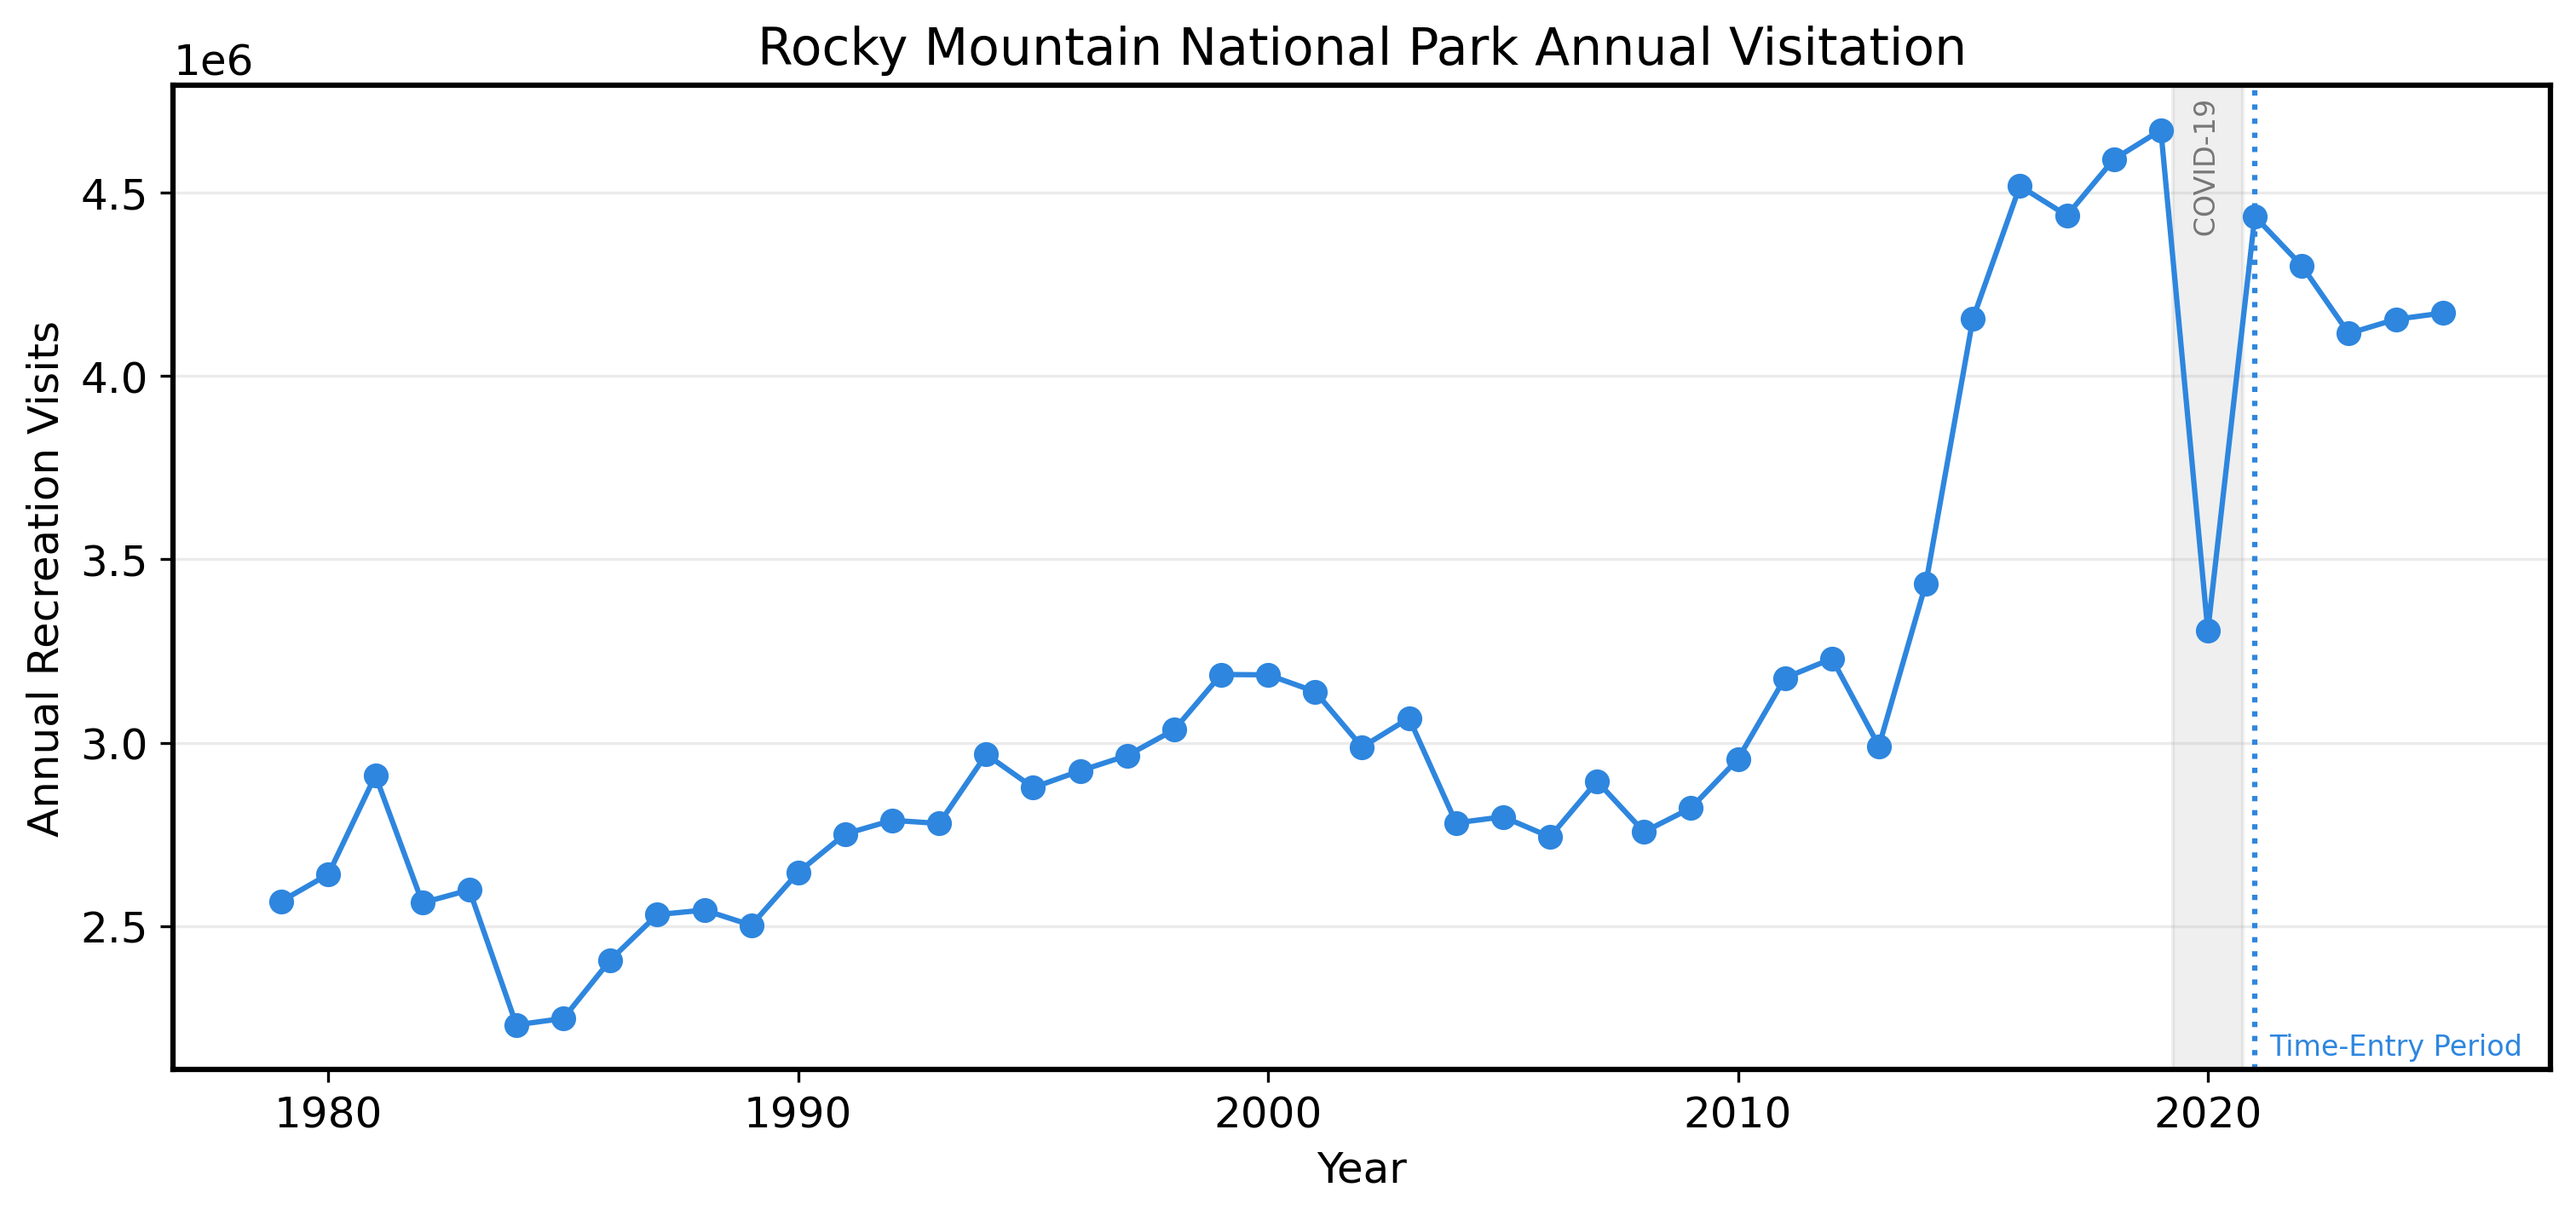

In [4]:
# Plot 

# Rocky Mountain National Park 
rmnp = annual[annual["park_code"] == "ROMO"]

fig, ax = plt.subplots(1, figsize=(12,5))


ax.plot(rmnp["year"], rmnp["visits"], marker="o", color ='#2E86DE')

### Hightlight when time-entry begins 
ax.axvline(2021, linestyle=":", color ='#2E86DE')
ax.text(2024, 2.21*1e6, "Time-Entry Period", rotation=0, va="top", ha="center", fontsize=8, color="#2E86DE")

ax.set_title("Rocky Mountain National Park Annual Visitation")

ax.set_ylabel("Annual Recreation Visits")
ax.set_xlabel("Year")

# Label highlighting covid-19
ax.text(2020, ax.get_ylim()[1]-10000, " COVID-19 ", rotation=90, va="top", ha="center", fontsize=8, color="#777")
ax.axvspan(2019.25, 2020.75, color="#888888", alpha=.13, zorder=0)

ax.grid(axis="y", alpha=.25)
plt.show()

#### Did total demand change?

Rocky Mountain National Park experienced substantial visitation growth in the decades leading up to timed entry implementation, increasing pressure on park infrastructure and visitor experience.

Following the introduction of timed entry in 2020 (blue dashed line), annual recreation visits declined compared with the pre-treatment peak. However, this decrease cannot be attributed to timed entry alone because implementation coincided with COVID-19 disruptions and broader changes in travel behavior.

A synthetic control approach is therefore needed to estimate how RMNP visitation may have changed relative to comparable parks experiencing similar external factors.

## 3. Monthly crowding patterns: Did the shape of the visitation change? 

In [5]:
monthly_pattern = (visits[visits["park_code"]=="ROMO"].groupby(["year","month"])["visits"].sum().reset_index())

# Before or after time-entry? 
monthly_pattern["period"] = None 

monthly_pattern.loc[monthly_pattern["year"].between(2015,2019), "period"] = "Before"

monthly_pattern.loc[monthly_pattern["year"].between(2021,2025), "period"] = "After"

monthly_pattern = (monthly_pattern.dropna(subset=["period"]))

In [6]:
monthly_pattern["period"].value_counts()

period
Before    60
After     60
Name: count, dtype: int64

In [7]:
monthly_avg = (monthly_pattern.groupby(["period", "month"])["visits"].mean().reset_index())

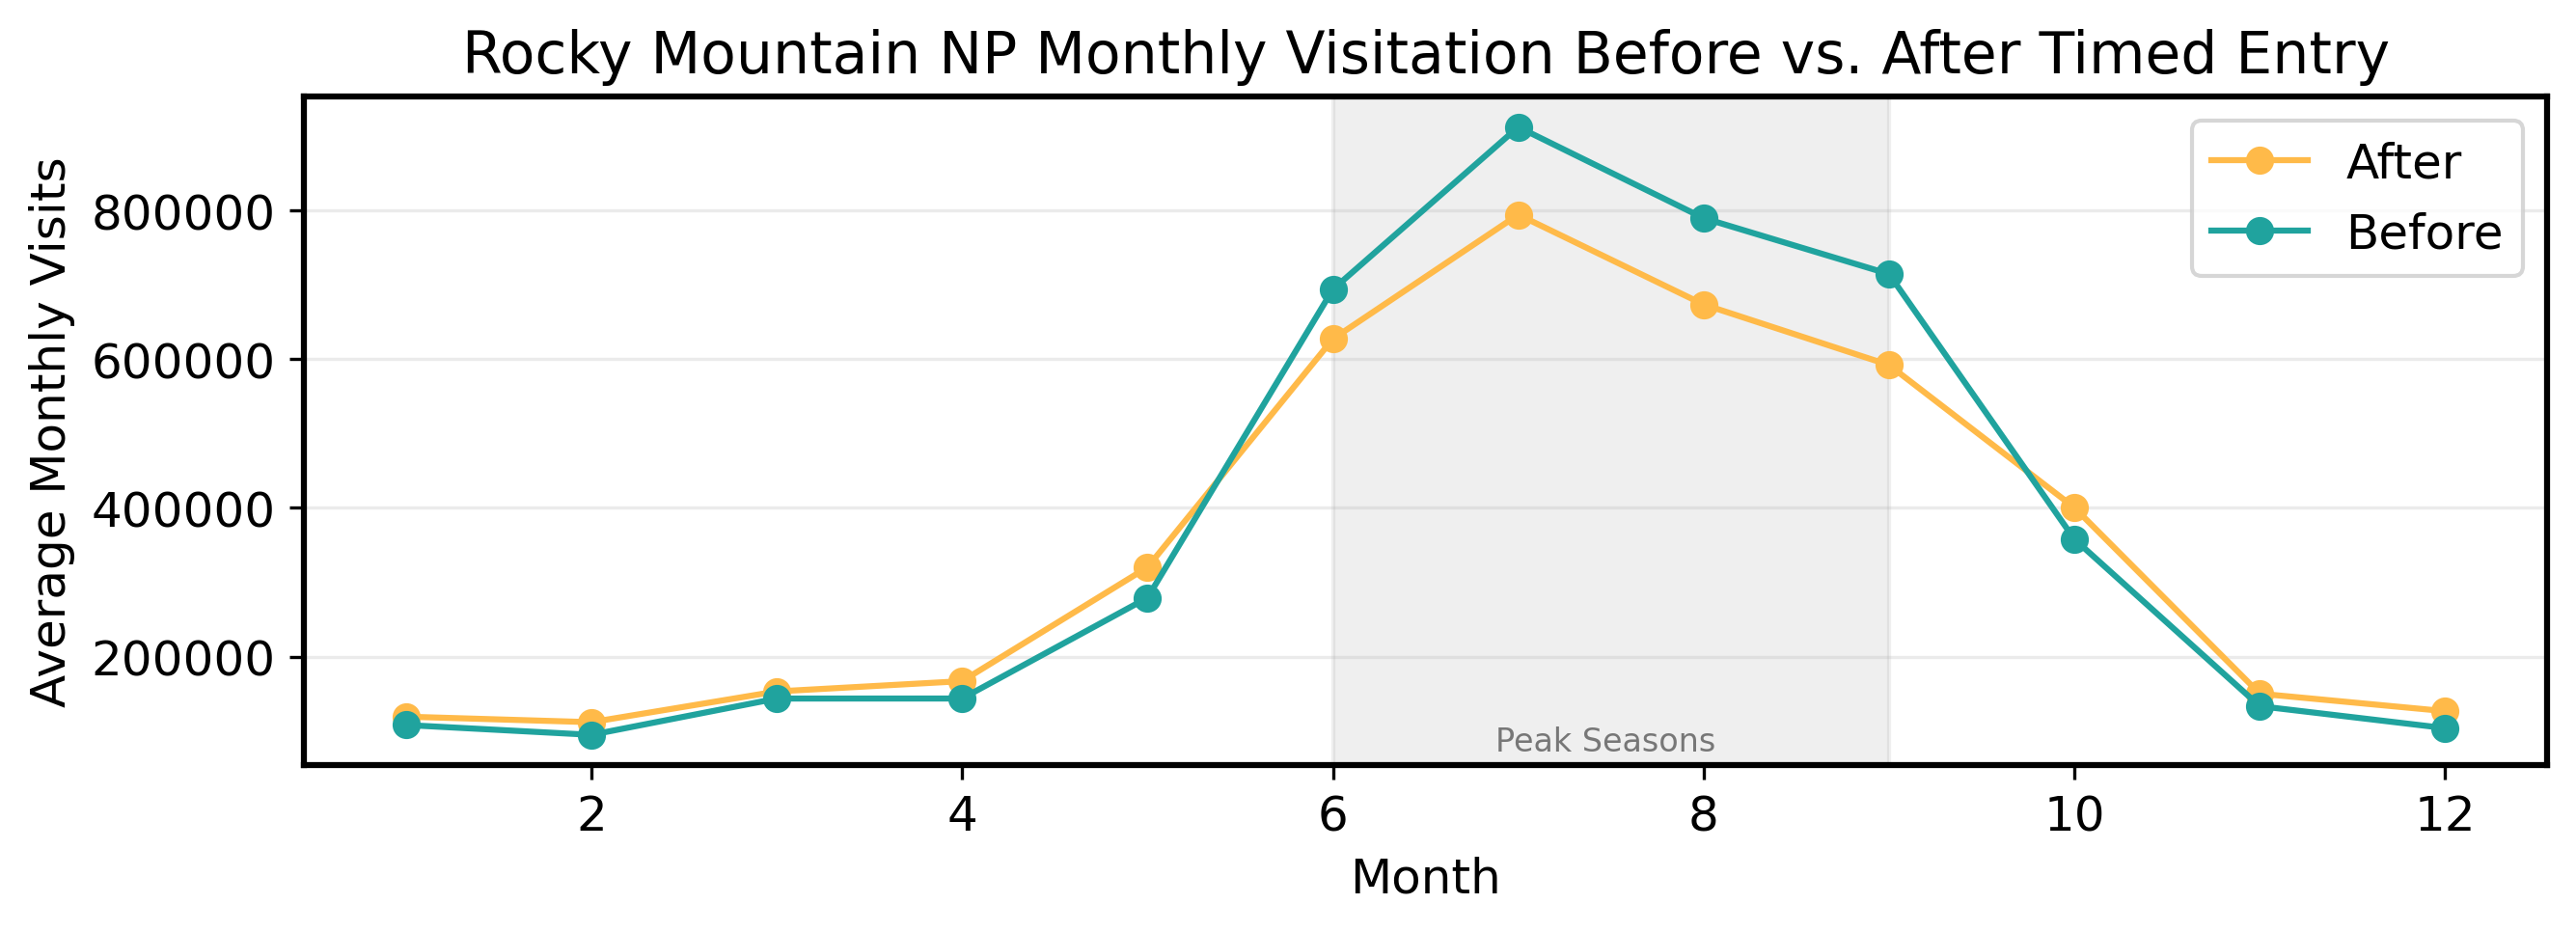

In [8]:
color_dict = {"Before": "#20a39e",
              "After": "#ffba49"}

for period in monthly_avg["period"].unique():
    data = monthly_avg[monthly_avg["period"] == period]

    plt.plot(data["month"], data["visits"], marker = 'o', label = period, c = color_dict[period])

plt.title("Rocky Mountain NP Monthly Visitation Before vs. After Timed Entry")
plt.xlabel("Month")
plt.ylabel("Average Monthly Visits")
plt.grid(axis="y", alpha=.25)

# Peak seasons June - Sept 
plt.axvspan(6, 9, color="#888888", alpha=.13, zorder=0)
plt.text(6+(9-6)/2, plt.ylim()[0]+20000, "Peak Seasons ", rotation=0, ha="center", fontsize=8, color="#777")

plt.legend()
plt.show()

#### Did the shape of visitation change?

While June through September remain the peak visitation months, average monthly visitation decreased during the peak season following the implementation of timed entry (yellow line). This suggests that visitor demand may have become less concentrated during traditionally high-traffic months, potentially reducing seasonal crowding pressure.

However, changes in visitation patterns may also reflect broader factors (e.g., COVID-related travel changes or shifts in tourism behavior), so causal impacts will be evaluated using synthetic control analysis.

## Peak Season Visits: Did summer crowd volume decrease?

In [9]:
# Annual total visits for each park 
annual_total = (visits.groupby(["park_code", "park_name", "year"])["visits"].sum().reset_index(name="annual_visits"))

# Peak season visits: June–September
peak_total = (visits[visits["month"].isin([6, 7, 8, 9])].groupby(["park_code", "park_name", "year"])["visits"].sum().reset_index(name="peak_season_visits"))

# Merge and calculate share
peak_share = annual_total.merge(peak_total, on=["park_code", "park_name", "year"],how="left")

# what fraction of the year's visitors came during the busiest months 
peak_share["peak_season_share"] = (peak_share["peak_season_visits"] /peak_share["annual_visits"])

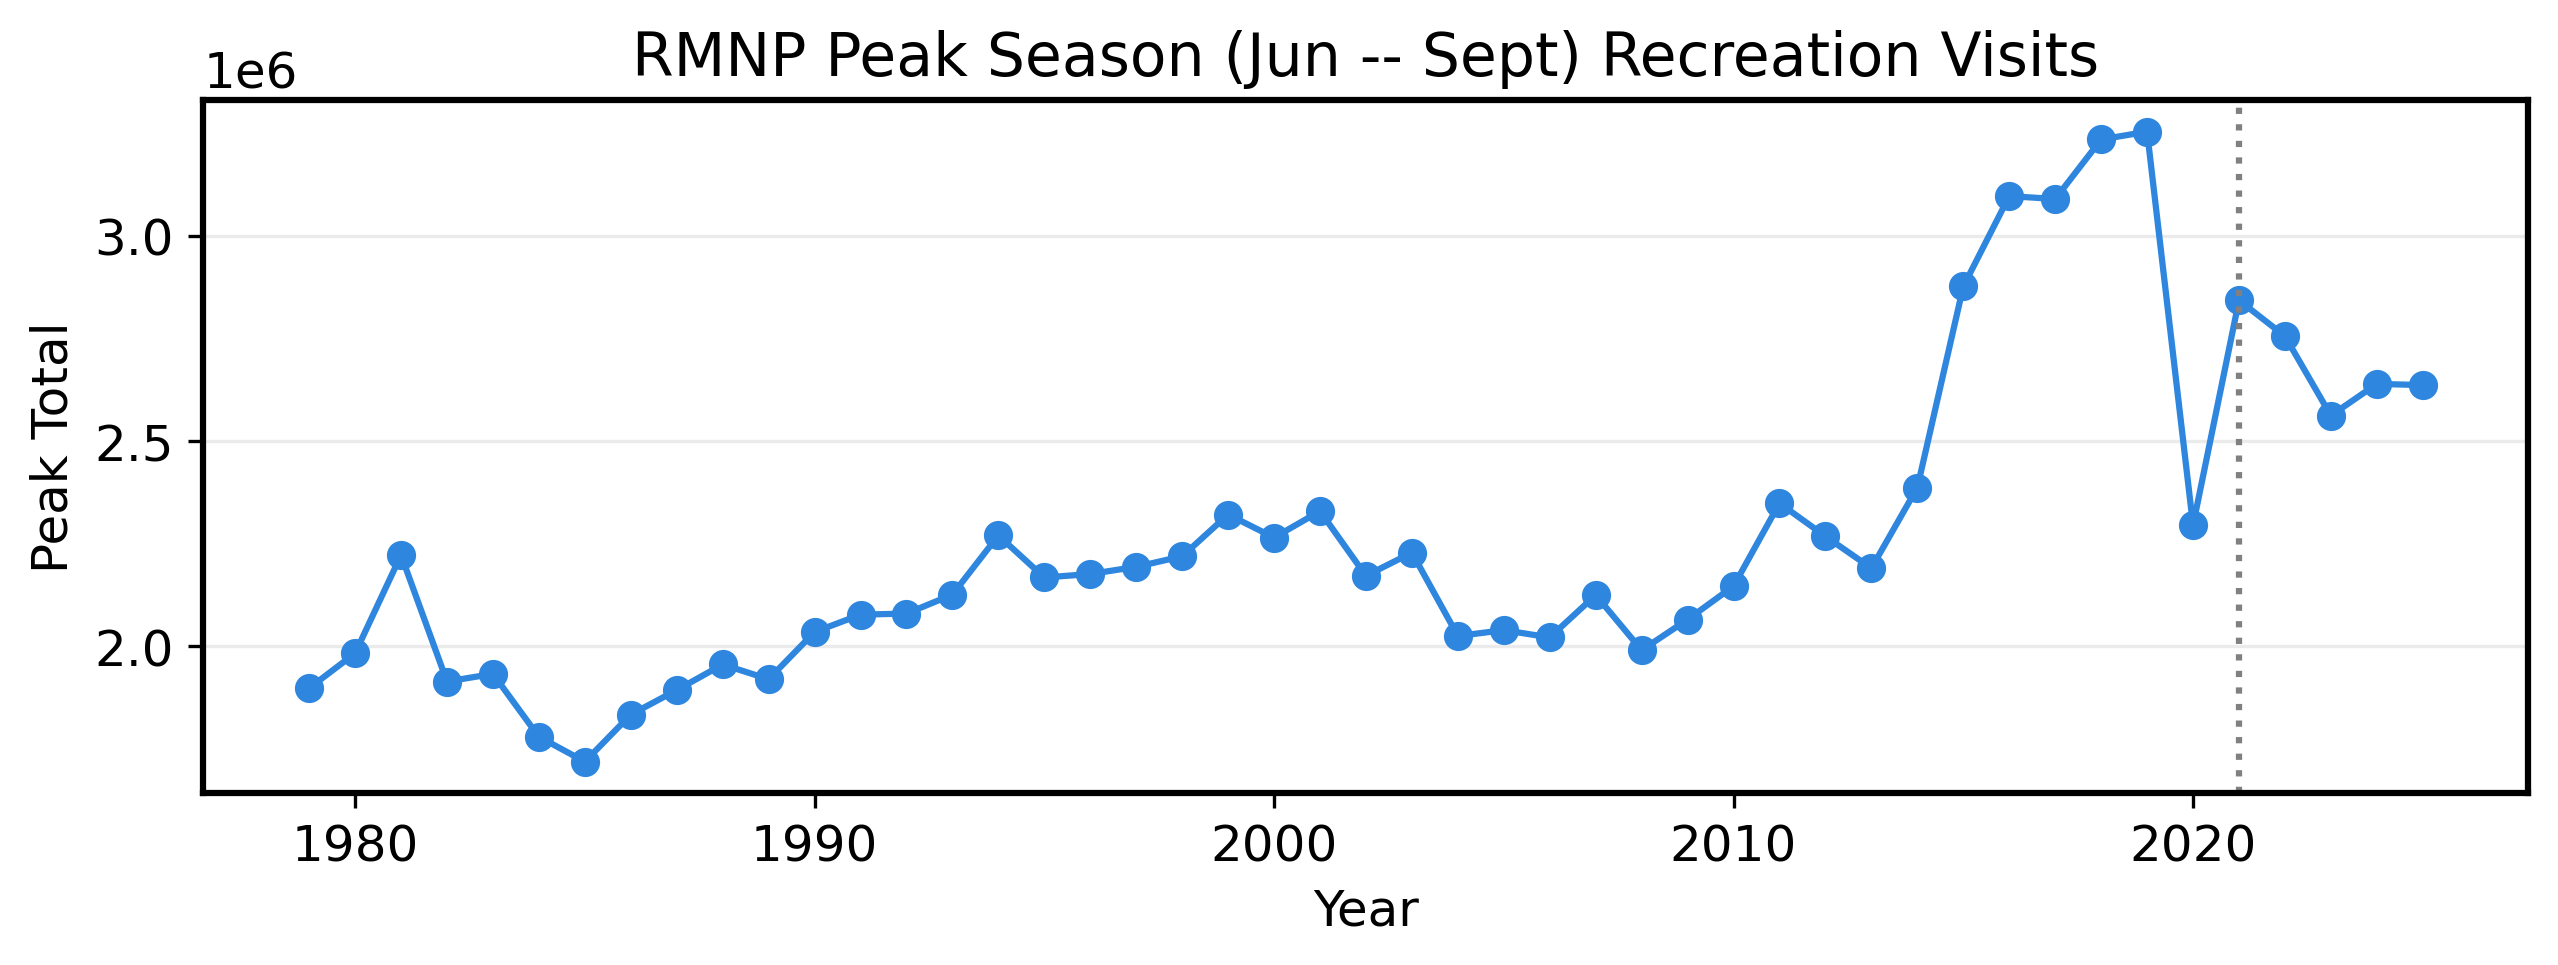

In [10]:
rmnp_peak = peak_share[peak_share["park_code"] == "ROMO"]

plt.plot(rmnp_peak["year"],rmnp_peak["peak_season_visits"],marker="o", color="#2E86DE")

plt.axvline(2021,linestyle=":",color ='gray')

plt.ylabel("Peak Total")
plt.xlabel("Year")
plt.title("RMNP Peak Season (Jun -- Sept) Recreation Visits")
plt.grid(axis="y", alpha=.25)

plt.show()

#### Did peak-season crowding decrease?

Peak-season visitation increased substantially prior to timed entry implementation, reaching its highest levels in the years immediately before 2020. Following timed entry implementation, June–September visitation declined; however, this observed decrease coincided with COVID-related disruptions, requiring a causal model to separate the effect of timed entry from broader changes in visitation patterns.

## Peak season share: Did demand spead throughout the year? 

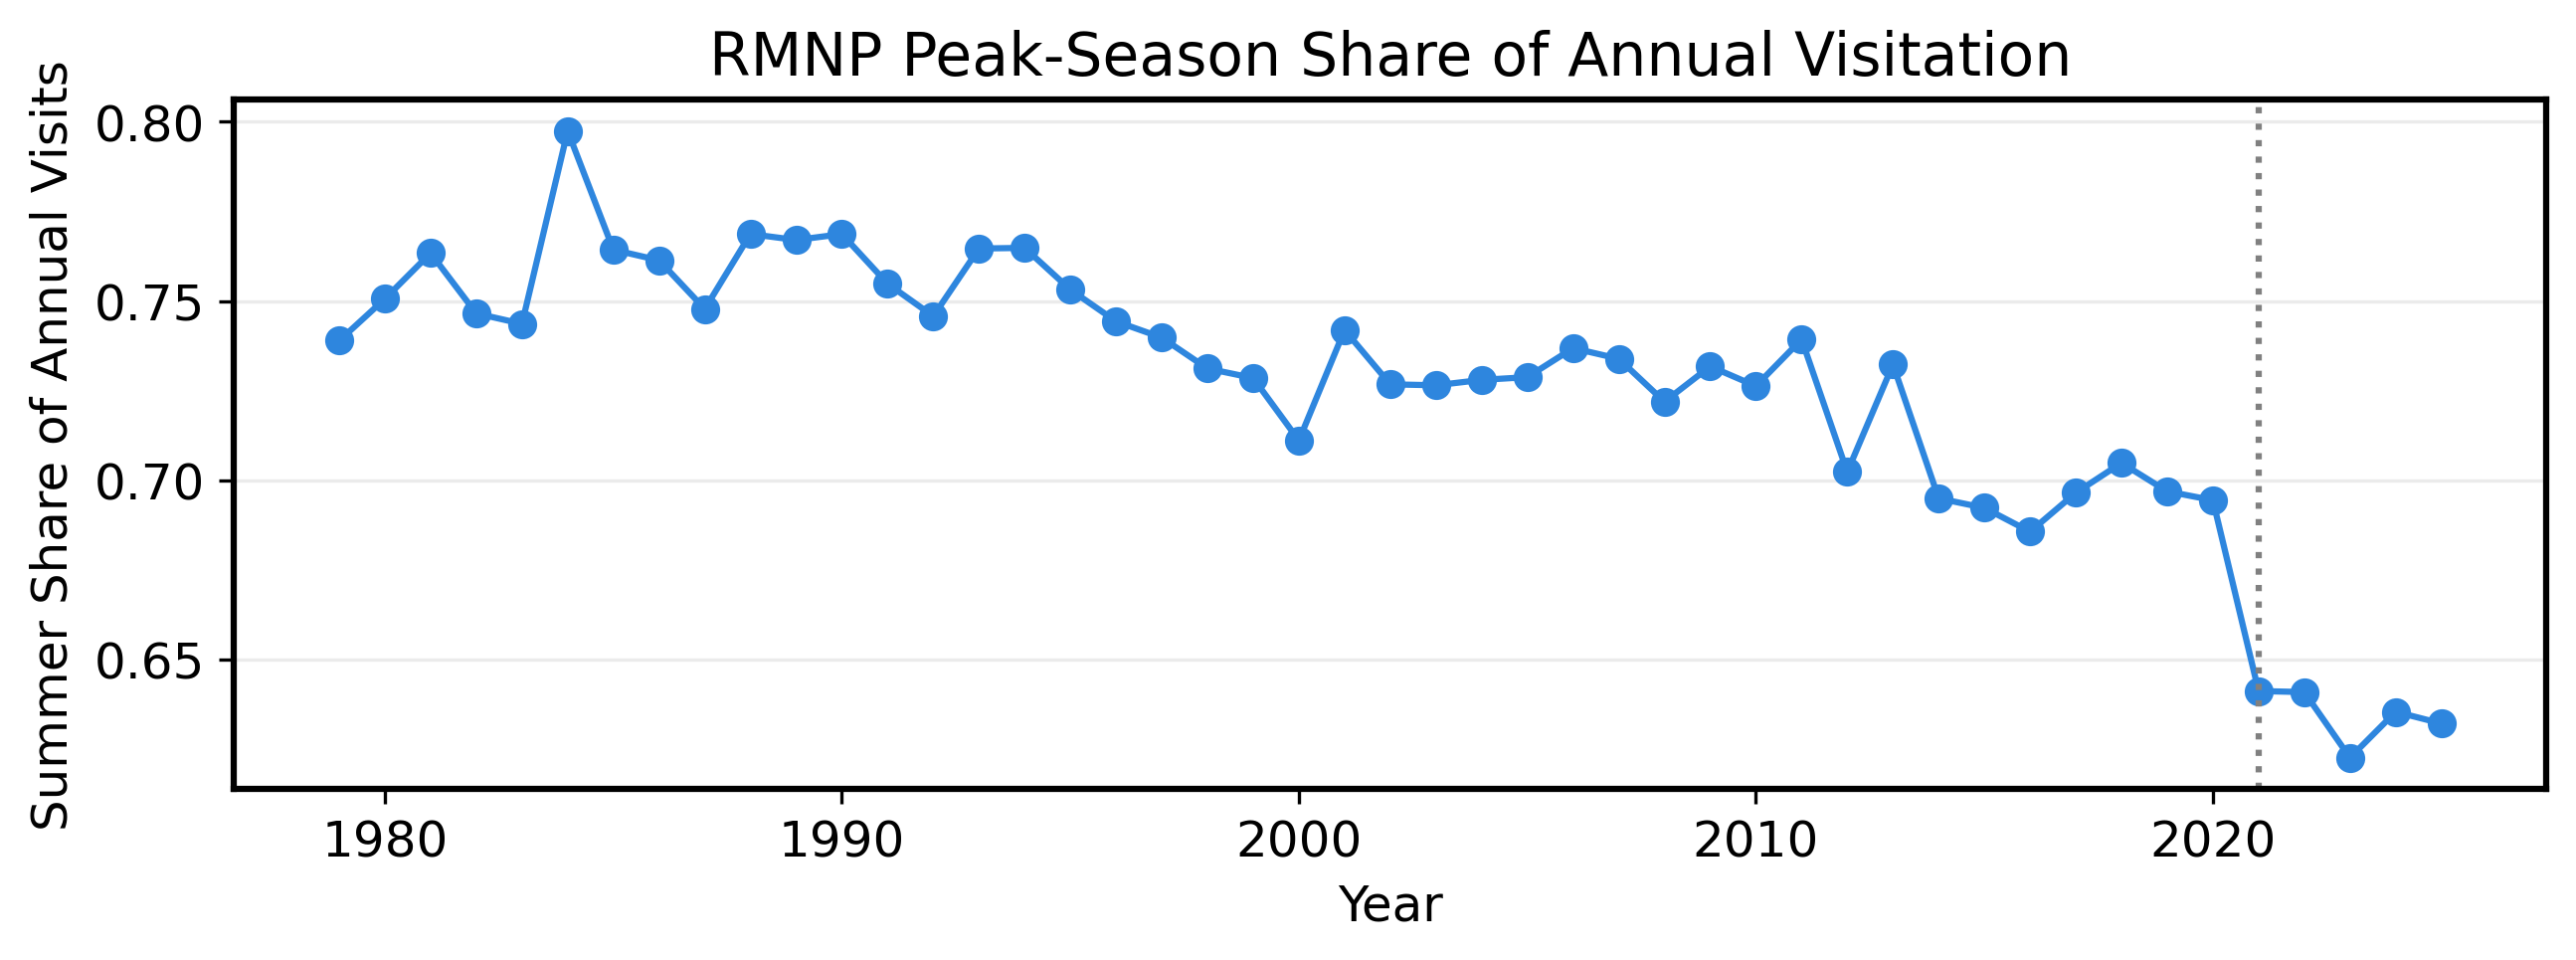

In [11]:
plt.plot(rmnp_peak["year"],rmnp_peak["peak_season_share"],marker="o", color="#2E86DE")

plt.axvline(2021,linestyle=":",color ='gray')

plt.title("RMNP Peak-Season Share of Annual Visitation")
plt.xlabel("Year")
plt.ylabel("Summer Share of Annual Visits")
plt.grid(axis="y", alpha=.25)

plt.show()

##### Did crowding become less concentrated?

Yes. Following the implementation of timed entry in 2020 (gray dashed line), the share of annual visitation occurring during the peak summer season decreased. Before timed entry, approximately 72% of RMNP visits occurred between June and September. After implementation, this declined to roughly 63%, representing about a 9 percentage point reduction in peak-season concentration.

This suggests that visitation demand became more evenly distributed throughout the year, though further causal analysis is needed to determine whether this shift was attributable to timed entry.

## Lets compare RMNP against donor parks 

> Was RMNP behaving similarly to potential control parks before timed entry?


In [12]:
donors = pd.read_csv(DONOR_FILE)

In [13]:
annual = (visits.groupby(["park_name","park_code","year"])["visits"].sum().reset_index(name="annual_visits"))

### add donor status 
annual = annual.merge(donors[["park_code", "comparable_donor"]], on="park_code", how="left")

comparison = annual[(annual["park_code"] == "ROMO") | (annual["comparable_donor"] == 1)].copy()

baseline = (comparison[comparison["year"] == 2010][["park_code", "annual_visits"]].rename(columns={"annual_visits": "baseline_visits"}))

comparison = comparison.merge(baseline,on="park_code")

comparison["visit_index"] = (comparison["annual_visits"] / comparison["baseline_visits"] *100)

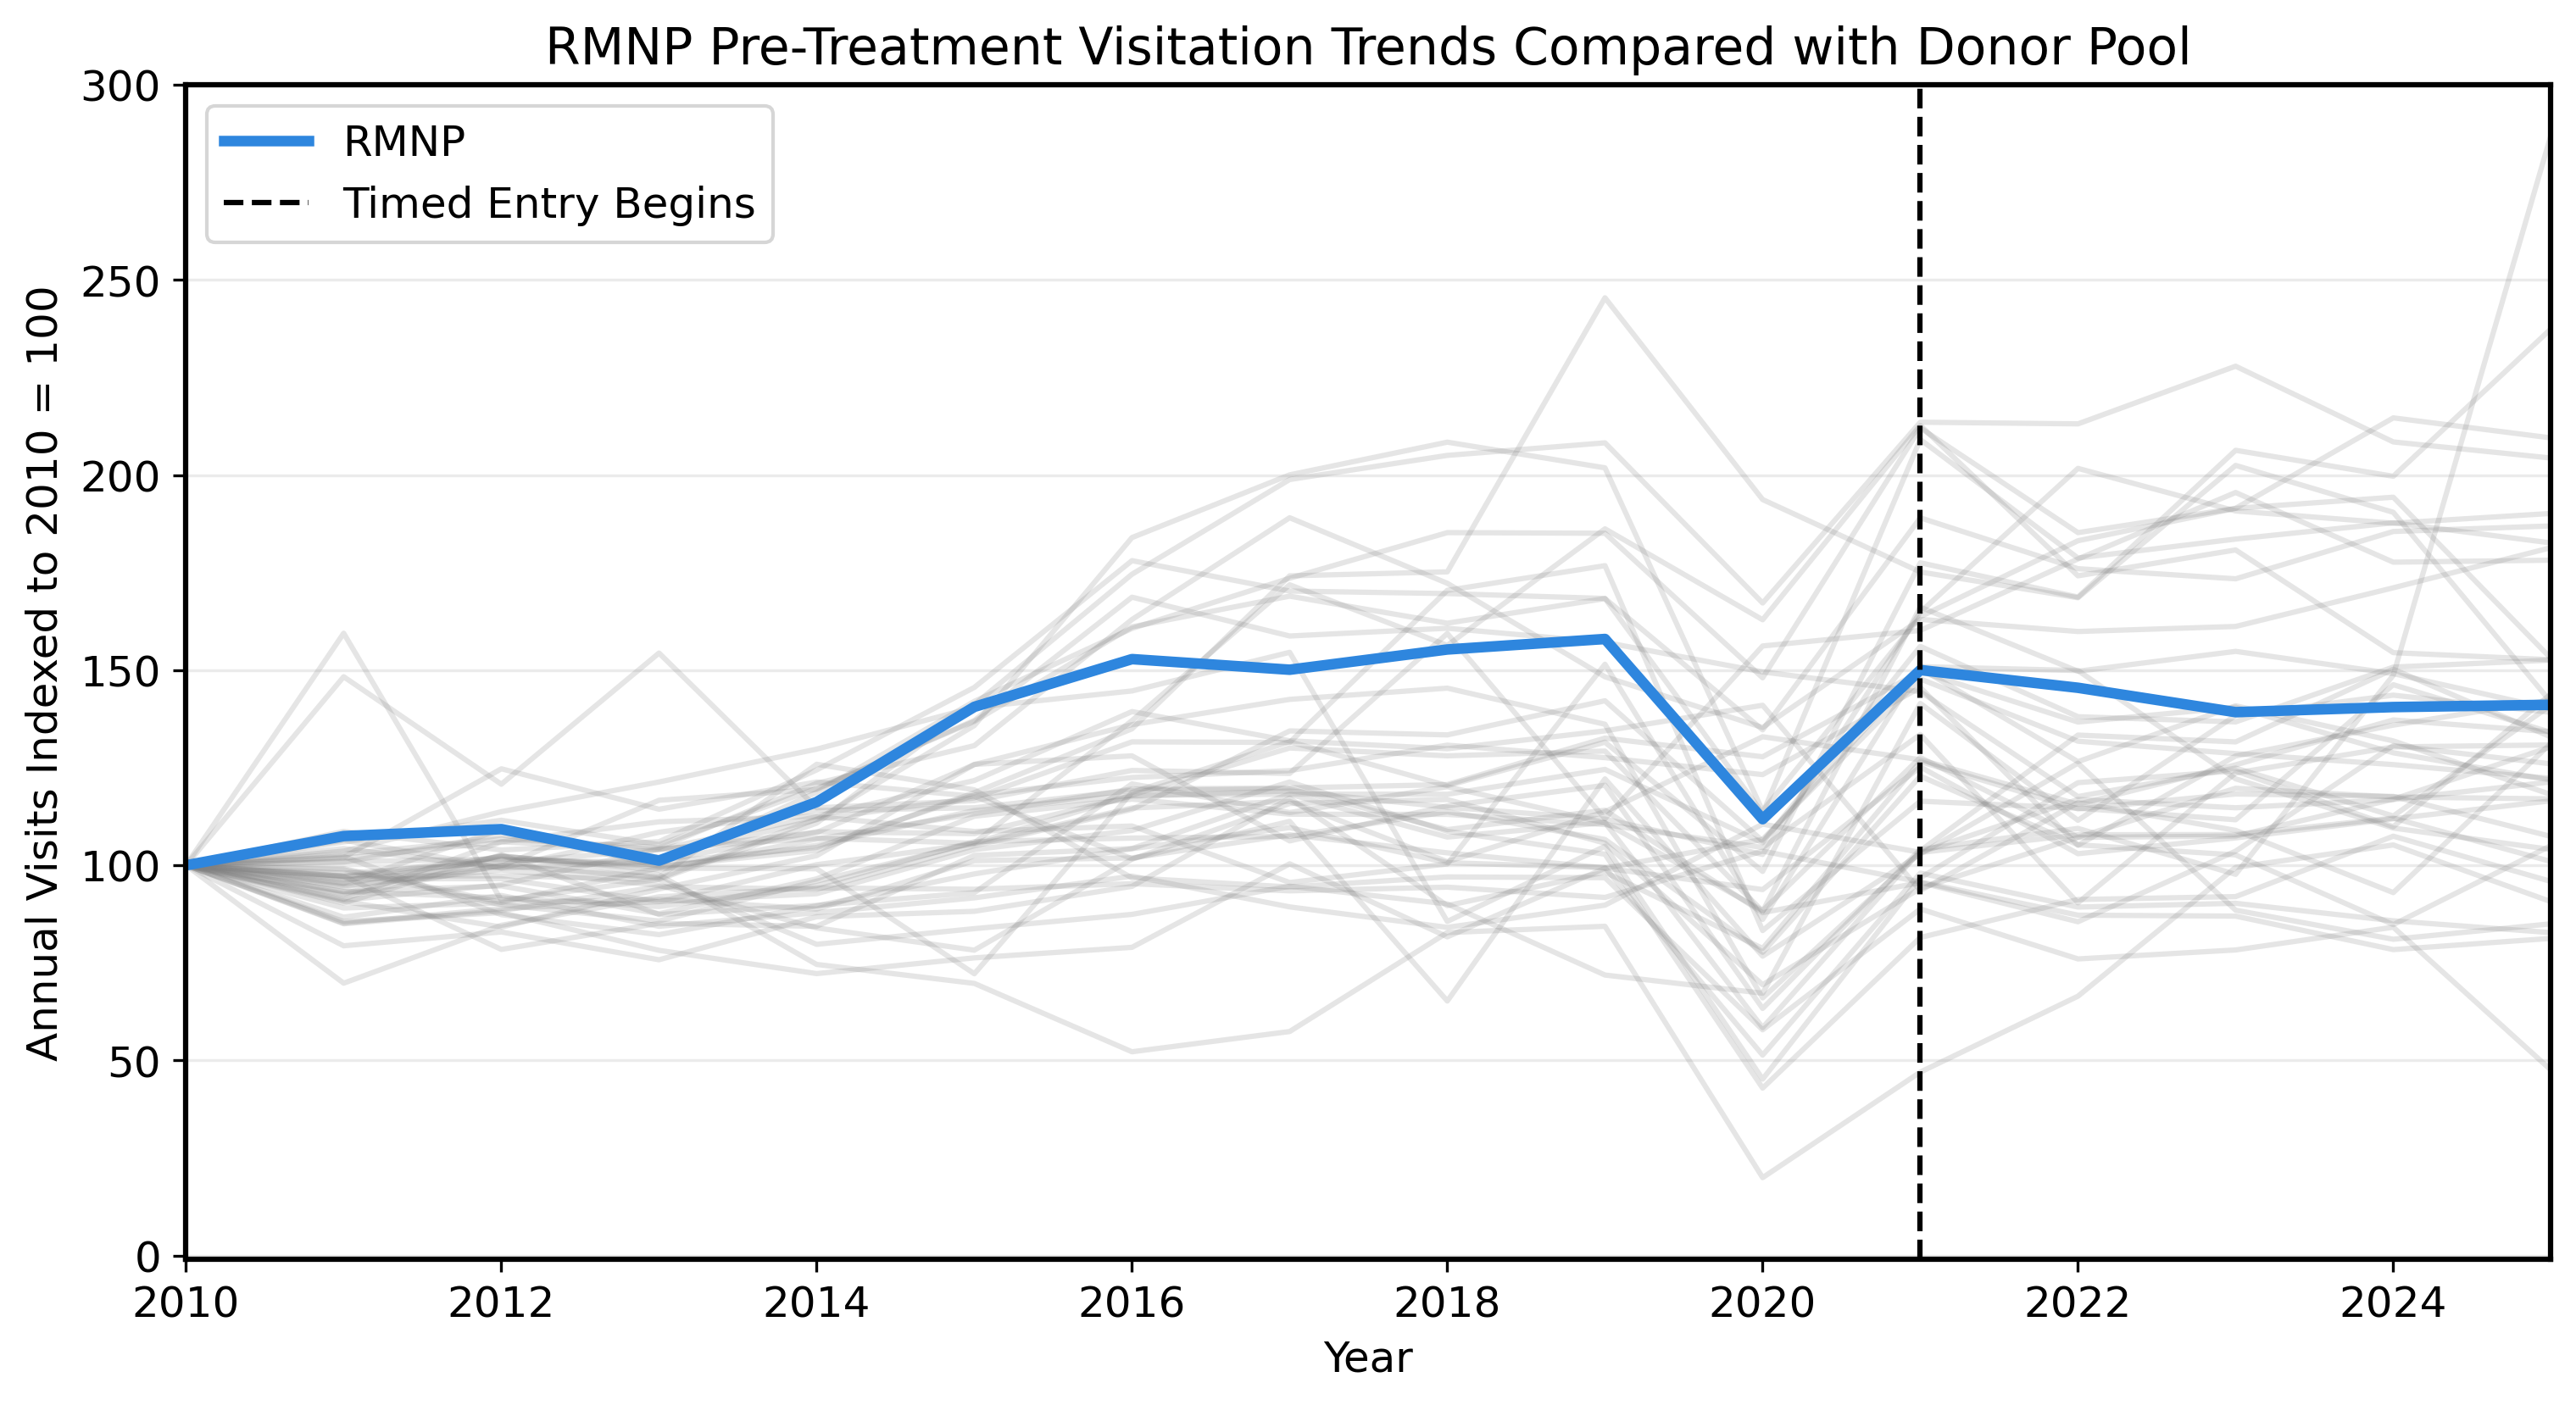

In [16]:
plt.figure(figsize=(12,6))

# donor parks
for park in comparison[
    comparison["park_code"]!="ROMO"]["park_code"].unique():

    temp = comparison[comparison["park_code"]==park]

    plt.plot(temp["year"], temp["visit_index"],alpha=0.2, c="gray")


# RMNP
rmnp = comparison[comparison["park_code"]=="ROMO"]
plt.plot(rmnp["year"], rmnp["visit_index"], linewidth=3, c="#2E86DE",label="RMNP")

plt.axvline(2021,linestyle="--",c="black",label="Timed Entry Begins")

plt.title("RMNP Pre-Treatment Visitation Trends Compared with Donor Pool")

plt.xlim([2010,2025])
plt.ylim([-1,300])

plt.ylabel("Annual Visits Indexed to 2010 = 100")
plt.xlabel("Year")
plt.legend()
plt.grid(axis="y", alpha=.25)
plt.savefig(FIGURE_PATH+'rmnp_vs_donorpool.png')
plt.show()

#### How did RMNP compare with potential donor parks?

Prior to timed entry implementation, RMNP visitation growth generally followed patterns observed among potential donor parks, suggesting that a weighted combination of donor units may provide a reasonable counterfactual.

The widespread decline across parks in 2020 highlights the importance of accounting for system-wide visitation shocks, such as COVID-related disruptions, rather than attributing RMNP's change solely to timed entry.
